In [21]:
import json
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [22]:
import pandas as pd

In [23]:
df=pd.read_csv("D:/client time and profit analysis/client_profitability_dataset.csv")

Raw Data Analysis

In [24]:
df.columns

Index(['Client_ID', 'Sector', 'Region', 'Project_Type', 'Subscription_Type',
       'Contract_Value', 'Monthly_Revenue', 'Total_Revenue', 'Employee_Hours',
       'Hourly_Rate', 'Operational_Cost', 'Support_Tickets', 'Escalations',
       'Client_Tenure_Months', 'Satisfaction_Score', 'Renewal_Status',
       'Discount_Offered', 'Payment_Delay_Days', 'Resource_Count',
       'Project_Duration_Days'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Client_ID              1000 non-null   int64  
 1   Sector                 1000 non-null   str    
 2   Region                 1000 non-null   str    
 3   Project_Type           1000 non-null   str    
 4   Subscription_Type      1000 non-null   str    
 5   Contract_Value         1000 non-null   int64  
 6   Monthly_Revenue        1000 non-null   int64  
 7   Total_Revenue          1000 non-null   int64  
 8   Employee_Hours         1000 non-null   int64  
 9   Hourly_Rate            1000 non-null   int64  
 10  Operational_Cost       1000 non-null   int64  
 11  Support_Tickets        1000 non-null   int64  
 12  Escalations            1000 non-null   int64  
 13  Client_Tenure_Months   1000 non-null   int64  
 14  Satisfaction_Score     1000 non-null   float64
 15  Renewal_Status  

In [26]:
numerical_data = df.select_dtypes(include=["int64", "float64"])
categorical_data = df.select_dtypes(include="str")

In [27]:
numerical_data.describe()

,Client_ID,Contract_Value,Monthly_Revenue,Total_Revenue,Employee_Hours,Hourly_Rate,Operational_Cost,Support_Tickets,Escalations,Client_Tenure_Months,Satisfaction_Score,Discount_Offered,Payment_Delay_Days,Resource_Count,Project_Duration_Days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,283307.332000,27706.652000,330020.842000,104.368000,1259.004000,104259.111000,24.280000,4.578000,30.291000,2.995230,14.56800,43.655000,4.878000,195.638000
std,288.819436,127148.705675,12865.149552,158012.558283,55.123436,427.011931,53755.917127,14.278918,2.893837,16.878305,1.136556,8.40881,25.780702,2.598436,96.280168
min,1.000000,52187.000000,5191.000000,60215.000000,10.000000,505.000000,10055.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000000,1.000000,30.000000
25%,250.750000,173299.500000,16403.000000,186574.000000,58.000000,892.750000,56933.500000,13.000000,2.000000,15.000000,2.030000,7.00000,21.000000,3.000000,112.000000
50%,500.500000,291845.500000,28284.000000,334606.500000,103.500000,1273.500000,105376.500000,24.000000,5.000000,30.000000,3.030000,15.00000,43.000000,5.000000,195.500000
75%,750.250000,389374.250000,38722.500000,467859.250000,153.000000,1615.250000,151041.750000,36.000000,7.000000,44.000000,3.940000,21.25000,66.000000,7.000000,276.250000
max,1000.000000,499962.000000,49993.000000,599767.000000,199.000000,1998.000000,198929.000000,49.000000,9.000000,59.000000,5.000000,29.00000,89.000000,9.000000,364.000000


In [28]:
numerical_data.isnull().sum()

Client_ID                0
Contract_Value           0
Monthly_Revenue          0
Total_Revenue            0
Employee_Hours           0
Hourly_Rate              0
Operational_Cost         0
Support_Tickets          0
Escalations              0
Client_Tenure_Months     0
Satisfaction_Score       0
Discount_Offered         0
Payment_Delay_Days       0
Resource_Count           0
Project_Duration_Days    0
dtype: int64

In [29]:
categorical_data.isnull().sum()

Sector               0
Region               0
Project_Type         0
Subscription_Type    0
Renewal_Status       0
dtype: int64

In [30]:
df.head(10)

,Client_ID,Sector,Region,Project_Type,Subscription_Type,Contract_Value,Monthly_Revenue,Total_Revenue,Employee_Hours,Hourly_Rate,Operational_Cost,Support_Tickets,Escalations,Client_Tenure_Months,Satisfaction_Score,Renewal_Status,Discount_Offered,Payment_Delay_Days,Resource_Count,Project_Duration_Days
0,1,Finance,West,Consulting,Basic,387501,28501,188447,129,1711,128017,46,8,36,1.43,No,13,37,1,346
1,2,Manufacturing,West,Support,Standard,252440,26113,521693,56,729,129496,47,6,51,1.82,Yes,10,54,9,140
2,3,IT,West,Consulting,Standard,128356,39441,65695,116,688,67089,15,4,9,1.59,No,28,27,1,363
3,4,Manufacturing,West,Support,Standard,328355,29690,238296,117,1938,157680,1,1,48,4.19,Yes,1,73,9,280
4,5,Manufacturing,West,Consulting,Basic,417570,48939,426645,18,509,138713,16,0,59,1.25,Yes,21,85,1,162
5,6,Healthcare,South,Consulting,Standard,317986,34345,382554,88,1637,26619,31,1,36,3.75,Yes,13,80,2,129
6,7,IT,West,Implementation,Basic,378996,49571,425898,164,1599,88006,42,0,38,2.47,No,23,21,2,201
7,8,IT,South,Support,Premium,437881,31829,413039,24,1175,24779,7,2,40,4.02,No,23,42,6,316
8,9,IT,West,Implementation,Basic,358112,40062,372849,28,1001,192112,2,5,59,4.86,Yes,26,82,7,148
9,10,Manufacturing,East,Support,Premium,329652,8630,252994,99,584,197397,11,7,29,1.46,Yes,6,80,1,204


In [31]:
df.Client_ID.unique

<bound method Series.unique of 0         1
1         2
2         3
3         4
4         5
       ... 
995     996
996     997
997     998
998     999
999    1000
Name: Client_ID, Length: 1000, dtype: int64>

In [16]:
df.duplicated().sum()

np.int64(0)

Outlier Identification and Treatment

In [32]:
df.head(5)

,Client_ID,Sector,Region,Project_Type,Subscription_Type,Contract_Value,Monthly_Revenue,Total_Revenue,Employee_Hours,Hourly_Rate,Operational_Cost,Support_Tickets,Escalations,Client_Tenure_Months,Satisfaction_Score,Renewal_Status,Discount_Offered,Payment_Delay_Days,Resource_Count,Project_Duration_Days
0,1,Finance,West,Consulting,Basic,387501,28501,188447,129,1711,128017,46,8,36,1.43,No,13,37,1,346
1,2,Manufacturing,West,Support,Standard,252440,26113,521693,56,729,129496,47,6,51,1.82,Yes,10,54,9,140
2,3,IT,West,Consulting,Standard,128356,39441,65695,116,688,67089,15,4,9,1.59,No,28,27,1,363
3,4,Manufacturing,West,Support,Standard,328355,29690,238296,117,1938,157680,1,1,48,4.19,Yes,1,73,9,280
4,5,Manufacturing,West,Consulting,Basic,417570,48939,426645,18,509,138713,16,0,59,1.25,Yes,21,85,1,162


Pictorial Identification of Outlier - Boxplot

In [34]:
numerical_data.columns

Index(['Client_ID', 'Contract_Value', 'Monthly_Revenue', 'Total_Revenue',
       'Employee_Hours', 'Hourly_Rate', 'Operational_Cost', 'Support_Tickets',
       'Escalations', 'Client_Tenure_Months', 'Satisfaction_Score',
       'Discount_Offered', 'Payment_Delay_Days', 'Resource_Count',
       'Project_Duration_Days'],
      dtype='str')

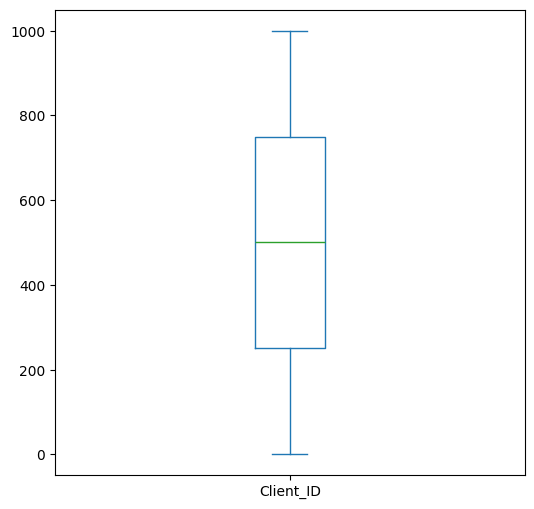

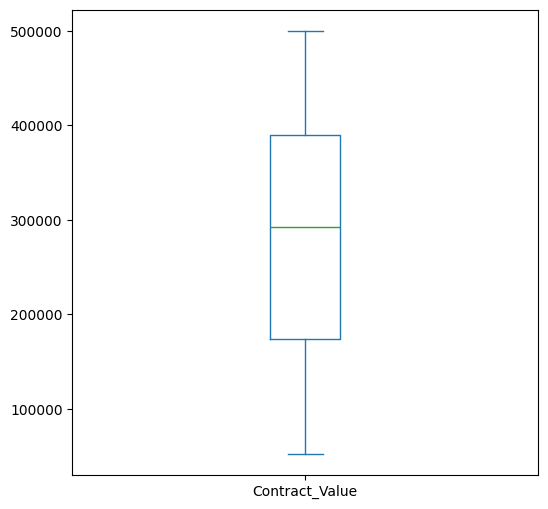

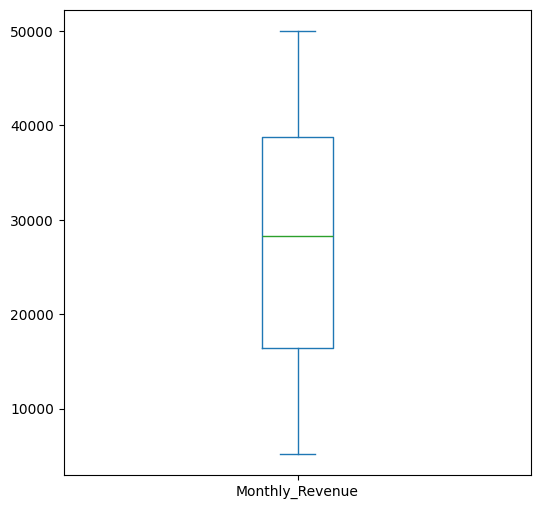

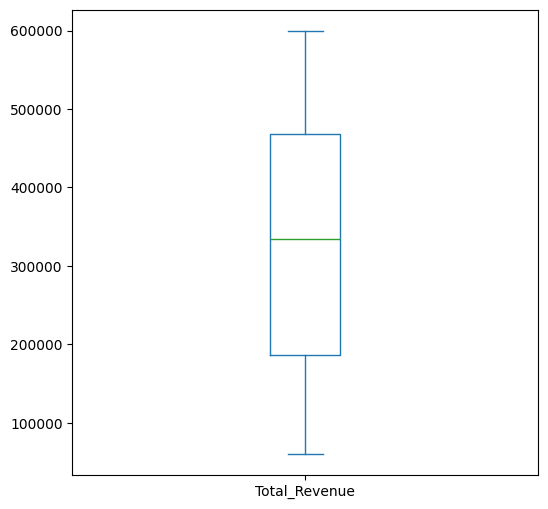

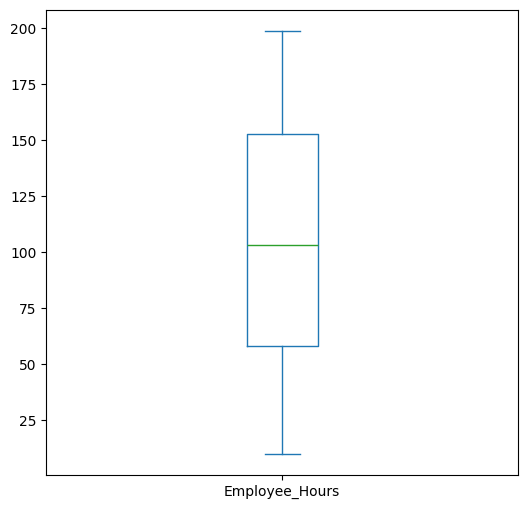

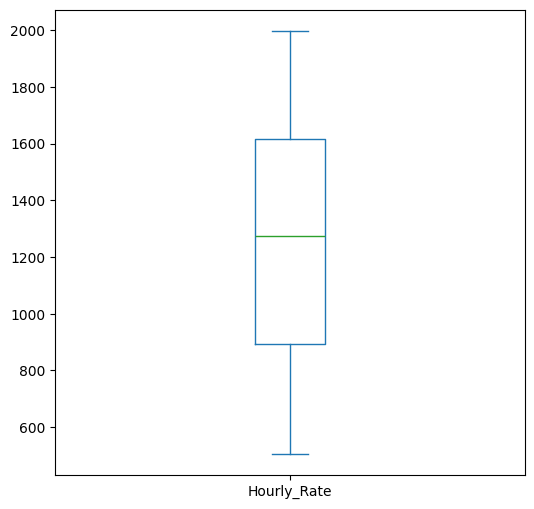

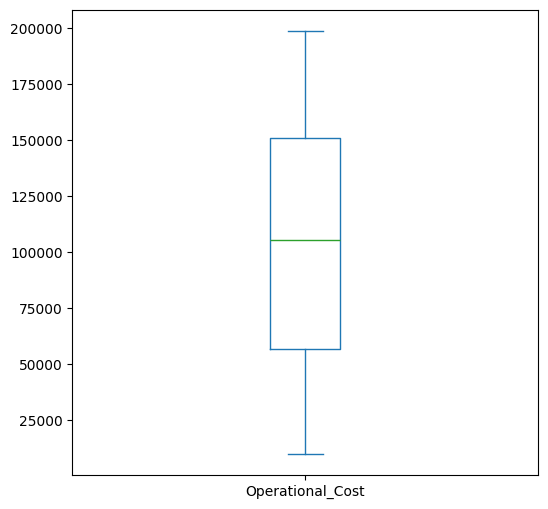

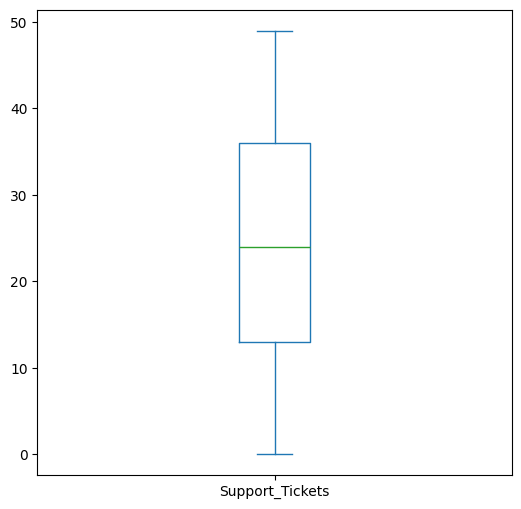

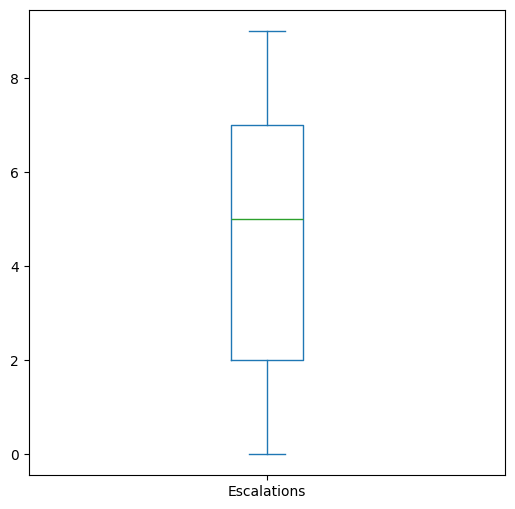

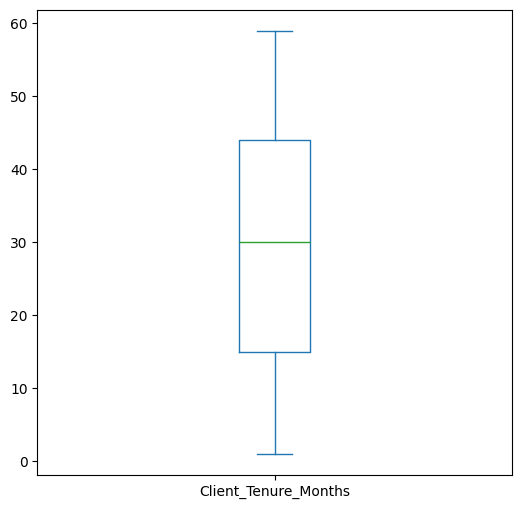

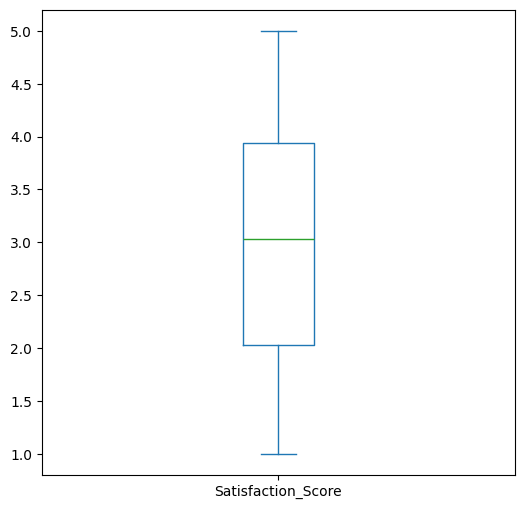

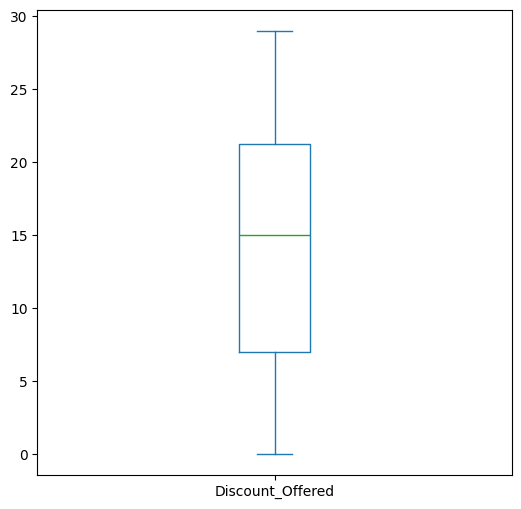

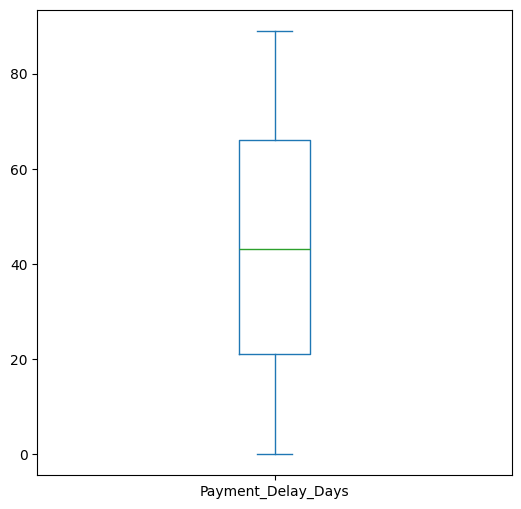

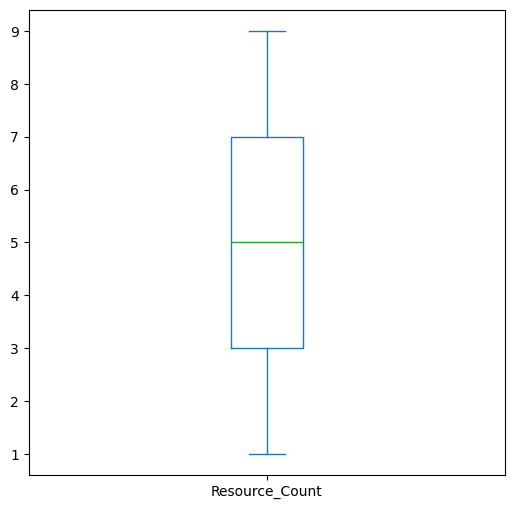

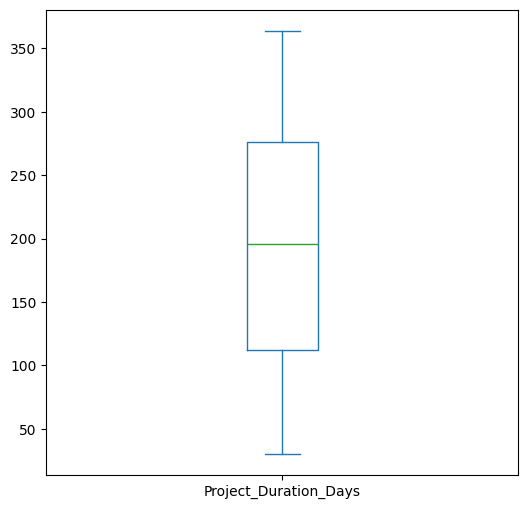

In [39]:
for i in numerical_data:
    df[i].plot(kind='box', subplots=True, layout=(2, 4), figsize=(20, 10))
    plt.tight_layout()
    plt.show()

In [40]:
df.describe()

,Client_ID,Contract_Value,Monthly_Revenue,Total_Revenue,Employee_Hours,Hourly_Rate,Operational_Cost,Support_Tickets,Escalations,Client_Tenure_Months,Satisfaction_Score,Discount_Offered,Payment_Delay_Days,Resource_Count,Project_Duration_Days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,283307.332000,27706.652000,330020.842000,104.368000,1259.004000,104259.111000,24.280000,4.578000,30.291000,2.995230,14.56800,43.655000,4.878000,195.638000
std,288.819436,127148.705675,12865.149552,158012.558283,55.123436,427.011931,53755.917127,14.278918,2.893837,16.878305,1.136556,8.40881,25.780702,2.598436,96.280168
min,1.000000,52187.000000,5191.000000,60215.000000,10.000000,505.000000,10055.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000000,1.000000,30.000000
25%,250.750000,173299.500000,16403.000000,186574.000000,58.000000,892.750000,56933.500000,13.000000,2.000000,15.000000,2.030000,7.00000,21.000000,3.000000,112.000000
50%,500.500000,291845.500000,28284.000000,334606.500000,103.500000,1273.500000,105376.500000,24.000000,5.000000,30.000000,3.030000,15.00000,43.000000,5.000000,195.500000
75%,750.250000,389374.250000,38722.500000,467859.250000,153.000000,1615.250000,151041.750000,36.000000,7.000000,44.000000,3.940000,21.25000,66.000000,7.000000,276.250000
max,1000.000000,499962.000000,49993.000000,599767.000000,199.000000,1998.000000,198929.000000,49.000000,9.000000,59.000000,5.000000,29.00000,89.000000,9.000000,364.000000


There are no outliers found the data is not skewed it is symmetrical

Outlier Identification - IQR Method

In [41]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [42]:
outlier_summary = {}
for col in numerical_data:
    if col in df.columns:
        outliers, low, high = detect_outliers_iqr(df, col)
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': len(outliers)/len(df)*100,
            'lower_bound': low,
            'upper_bound': high
        }
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

Client_ID: 0 outliers (0.0%)
Contract_Value: 0 outliers (0.0%)
Monthly_Revenue: 0 outliers (0.0%)
Total_Revenue: 0 outliers (0.0%)
Employee_Hours: 0 outliers (0.0%)
Hourly_Rate: 0 outliers (0.0%)
Operational_Cost: 0 outliers (0.0%)
Support_Tickets: 0 outliers (0.0%)
Escalations: 0 outliers (0.0%)
Client_Tenure_Months: 0 outliers (0.0%)
Satisfaction_Score: 0 outliers (0.0%)
Discount_Offered: 0 outliers (0.0%)
Payment_Delay_Days: 0 outliers (0.0%)
Resource_Count: 0 outliers (0.0%)
Project_Duration_Days: 0 outliers (0.0%)


IQR also tells there are no Outliers

Column Derivations

In [43]:
df["Profit"]= df["Total_Revenue"] - df["Operational_Cost"]

In [46]:
df['Result'] = np.where(df['Profit'] <=0, 'Loss', 'Profit')

In [47]:
df["Profit_margin"] = df['Profit'] / df['Total_Revenue']

In [48]:
df["Revenue_per_Hour"] = np.where(df["Employee_Hours"] != 0, df["Total_Revenue"] / df["Employee_Hours"], 0)
df["Cost_per_Hour"] = np.where(df["Employee_Hours"] != 0, df["Operational_Cost"] / df["Employee_Hours"], 0)
df["Support_Burden"] = np.where(df["Resource_Count"] != 0, df["Support_Tickets"] / df["Resource_Count"], 0)
df["Escalation_Rate"] = np.where(df["Support_Tickets"] != 0, df["Escalations"] / df["Support_Tickets"], 0)
df["High_Delay_Flag"] = (df["Payment_Delay_Days"] > 45).astype(int)
df["Low_Sat_Flag"] = (df["Satisfaction_Score"] < 3).astype(int)
df["Churn_Risk_Score"] = (
    df["High_Delay_Flag"] * 25 +
    df["Low_Sat_Flag"] * 25 +
    (df["Escalations"] > 5).astype(int) * 20 +
    (df["Discount_Offered"] > df["Discount_Offered"].median()).astype(int) * 10 +
    (df["Renewal_Status"].eq("No")).astype(int) * 20
)

In [50]:
df.columns

Index(['Client_ID', 'Sector', 'Region', 'Project_Type', 'Subscription_Type',
       'Contract_Value', 'Monthly_Revenue', 'Total_Revenue', 'Employee_Hours',
       'Hourly_Rate', 'Operational_Cost', 'Support_Tickets', 'Escalations',
       'Client_Tenure_Months', 'Satisfaction_Score', 'Renewal_Status',
       'Discount_Offered', 'Payment_Delay_Days', 'Resource_Count',
       'Project_Duration_Days', 'Profit', 'Result', 'Profit_margin',
       'Revenue_per_Hour', 'Cost_per_Hour', 'Support_Burden',
       'Escalation_Rate', 'High_Delay_Flag', 'Low_Sat_Flag',
       'Churn_Risk_Score'],
      dtype='str')

In [53]:
df.isnull().sum()

Client_ID                0
Sector                   0
Region                   0
Project_Type             0
Subscription_Type        0
Contract_Value           0
Monthly_Revenue          0
Total_Revenue            0
Employee_Hours           0
Hourly_Rate              0
Operational_Cost         0
Support_Tickets          0
Escalations              0
Client_Tenure_Months     0
Satisfaction_Score       0
Renewal_Status           0
Discount_Offered         0
Payment_Delay_Days       0
Resource_Count           0
Project_Duration_Days    0
Profit                   0
Result                   0
Profit_margin            0
Revenue_per_Hour         0
Cost_per_Hour            0
Support_Burden           0
Escalation_Rate          0
High_Delay_Flag          0
Low_Sat_Flag             0
Churn_Risk_Score         0
dtype: int64

In [56]:
df.describe()

,Client_ID,Contract_Value,Monthly_Revenue,Total_Revenue,Employee_Hours,Hourly_Rate,Operational_Cost,Support_Tickets,Escalations,Client_Tenure_Months,...,Project_Duration_Days,Profit,Profit_margin,Revenue_per_Hour,Cost_per_Hour,Support_Burden,Escalation_Rate,High_Delay_Flag,Low_Sat_Flag,Churn_Risk_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,283307.332000,27706.652000,330020.842000,104.368000,1259.004000,104259.111000,24.280000,4.578000,30.291000,...,195.638000,225761.73100,0.548635,5430.502866,1713.173713,7.984668,0.376207,0.468000,0.489000,47.215000
std,288.819436,127148.705675,12865.149552,158012.558283,55.123436,427.011931,53755.917127,14.278918,2.893837,16.878305,...,96.280168,165542.50489,0.447704,7024.965126,2224.749626,9.052712,0.746728,0.499225,0.500129,22.307317
min,1.000000,52187.000000,5191.000000,60215.000000,10.000000,505.000000,10055.000000,0.000000,0.000000,1.000000,...,30.000000,-135840.00000,-2.244733,313.934343,62.022346,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250.750000,173299.500000,16403.000000,186574.000000,58.000000,892.750000,56933.500000,13.000000,2.000000,15.000000,...,112.000000,87546.25000,0.456837,1859.133785,551.352404,2.482143,0.074074,0.000000,0.000000,30.000000
50%,500.500000,291845.500000,28284.000000,334606.500000,103.500000,1273.500000,105376.500000,24.000000,5.000000,30.000000,...,195.500000,233842.00000,0.681990,3080.405556,991.021193,5.000000,0.178571,0.000000,0.000000,45.000000
75%,750.250000,389374.250000,38722.500000,467859.250000,153.000000,1615.250000,151041.750000,36.000000,7.000000,44.000000,...,276.250000,359311.50000,0.830660,5990.346215,1833.389167,9.333333,0.333333,1.000000,1.000000,65.000000
max,1000.000000,499962.000000,49993.000000,599767.000000,199.000000,1998.000000,198929.000000,49.000000,9.000000,59.000000,...,364.000000,580713.00000,0.982938,55766.600000,17836.100000,49.000000,9.000000,1.000000,1.000000,100.000000


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Client_ID              1000 non-null   int64  
 1   Sector                 1000 non-null   str    
 2   Region                 1000 non-null   str    
 3   Project_Type           1000 non-null   str    
 4   Subscription_Type      1000 non-null   str    
 5   Contract_Value         1000 non-null   int64  
 6   Monthly_Revenue        1000 non-null   int64  
 7   Total_Revenue          1000 non-null   int64  
 8   Employee_Hours         1000 non-null   int64  
 9   Hourly_Rate            1000 non-null   int64  
 10  Operational_Cost       1000 non-null   int64  
 11  Support_Tickets        1000 non-null   int64  
 12  Escalations            1000 non-null   int64  
 13  Client_Tenure_Months   1000 non-null   int64  
 14  Satisfaction_Score     1000 non-null   float64
 15  Renewal_Status  

In [79]:
numerical_data_after_DC = df.select_dtypes(include=["int64", "float64"])
categorical_data_after_DC = df.select_dtypes(include="str")

In [81]:
zeros_and_negative_presented = []


for col in numerical_data_after_DC:
    count = (df[col] <= 0).sum()
    if count > 0:
        zeros_and_negative_presented.append(col)
    print(col, count)

print("Columns with zero/negative values:", zeros_and_negative_presented)

Client_ID 0
Contract_Value 0
Monthly_Revenue 0
Total_Revenue 0
Employee_Hours 0
Hourly_Rate 0
Operational_Cost 0
Support_Tickets 25
Escalations 91
Client_Tenure_Months 0
Satisfaction_Score 0
Discount_Offered 24
Payment_Delay_Days 11
Resource_Count 0
Project_Duration_Days 0
Profit 93
Profit_margin 93
Revenue_per_Hour 0
Cost_per_Hour 0
Support_Burden 25
Escalation_Rate 112
High_Delay_Flag 532
Low_Sat_Flag 511
Churn_Risk_Score 42
Columns with zero/negative values: ['Support_Tickets', 'Escalations', 'Discount_Offered', 'Payment_Delay_Days', 'Profit', 'Profit_margin', 'Support_Burden', 'Escalation_Rate', 'High_Delay_Flag', 'Low_Sat_Flag', 'Churn_Risk_Score']


In [82]:
print(zeros_and_negative_presented)

['Support_Tickets', 'Escalations', 'Discount_Offered', 'Payment_Delay_Days', 'Profit', 'Profit_margin', 'Support_Burden', 'Escalation_Rate', 'High_Delay_Flag', 'Low_Sat_Flag', 'Churn_Risk_Score']


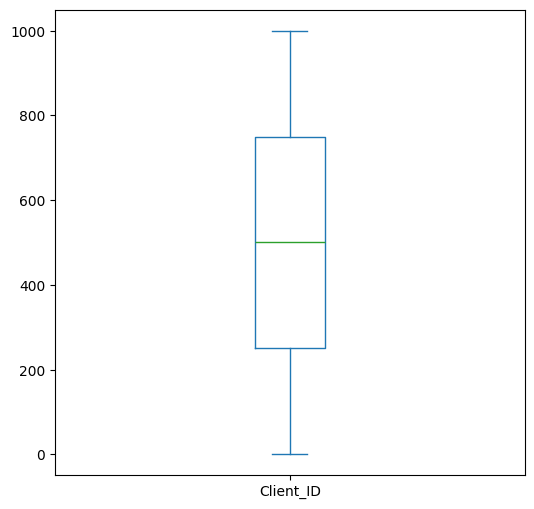

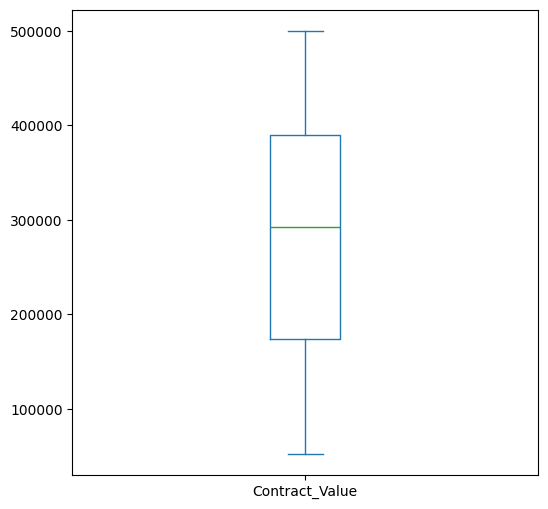

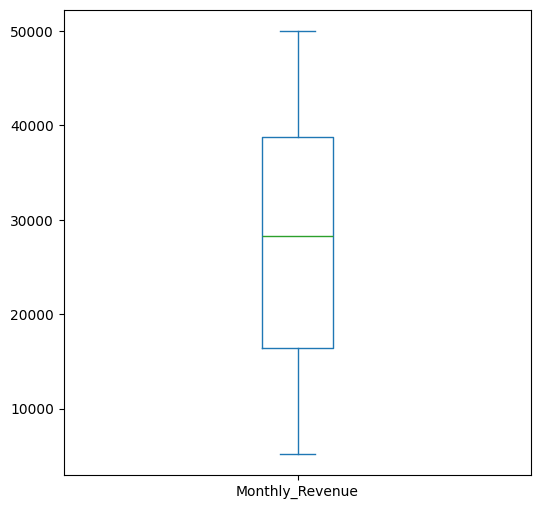

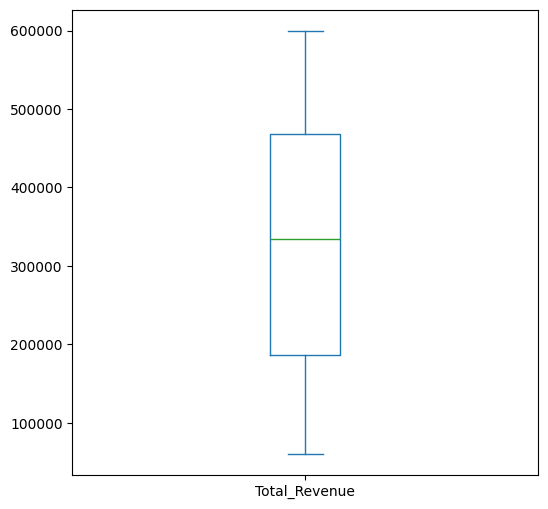

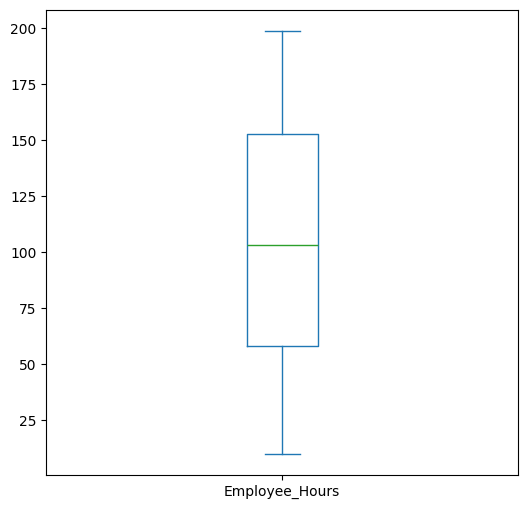

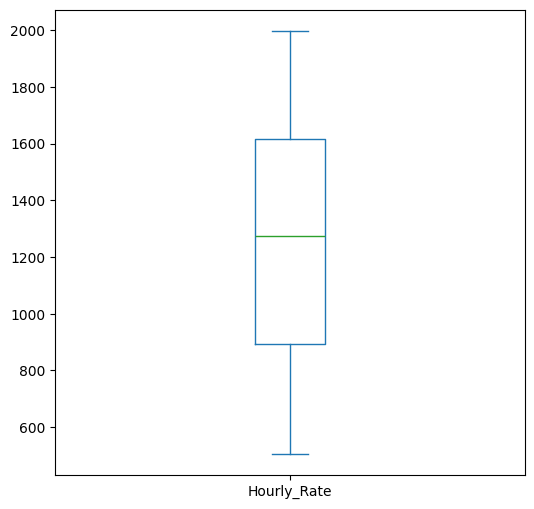

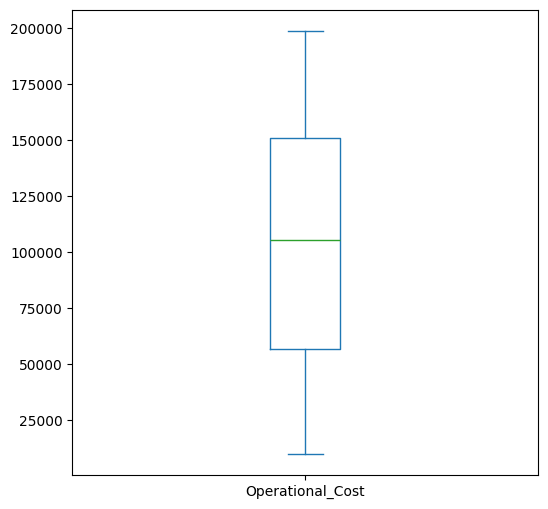

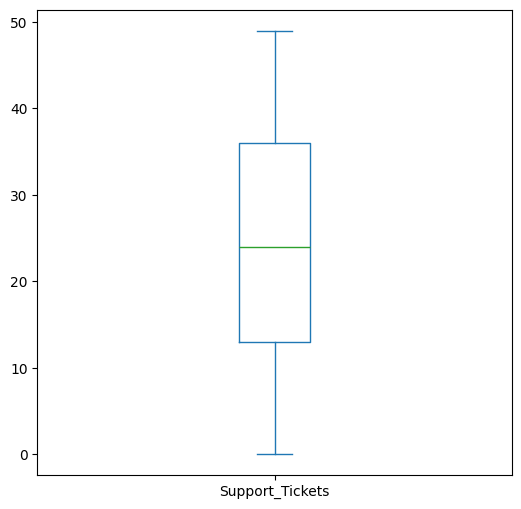

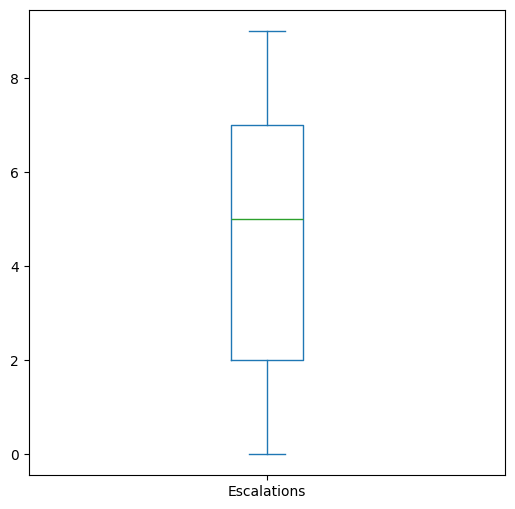

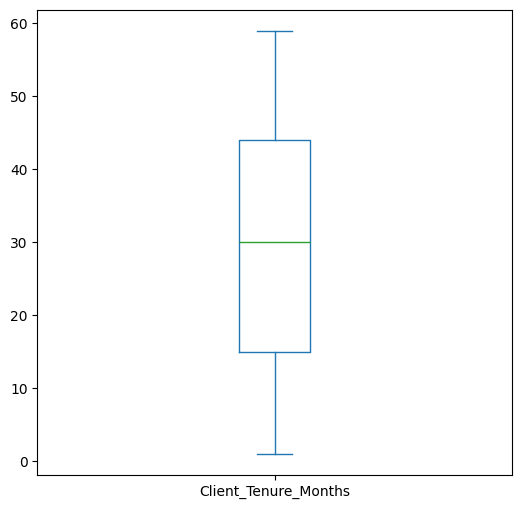

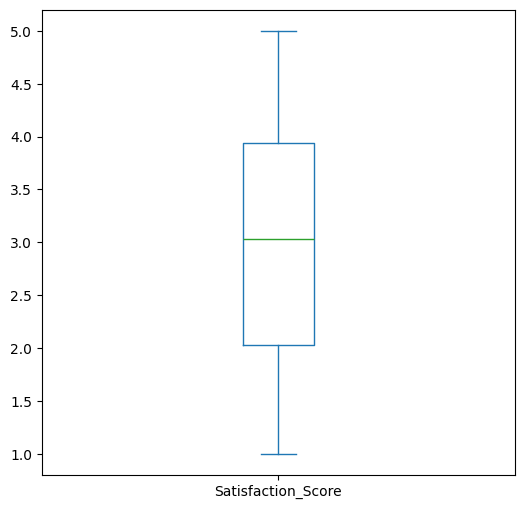

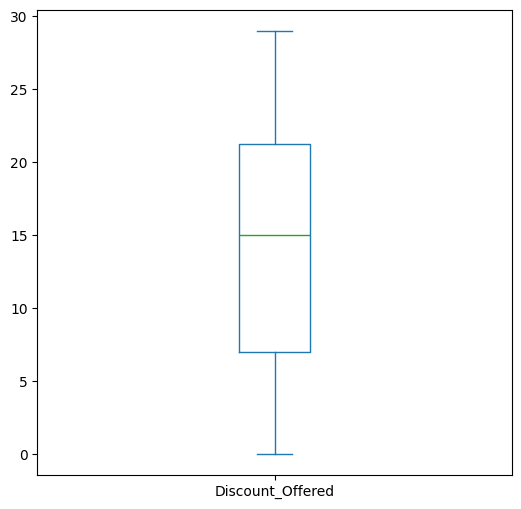

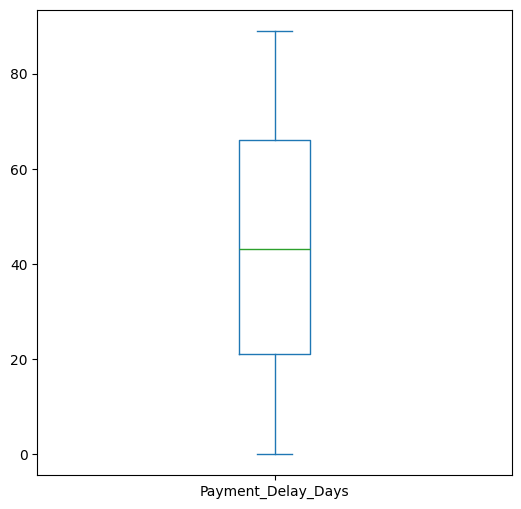

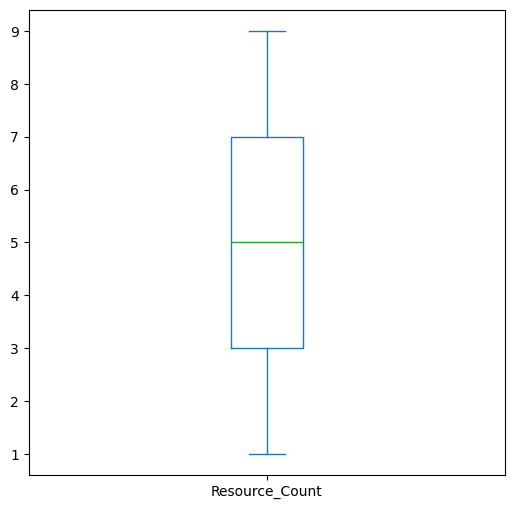

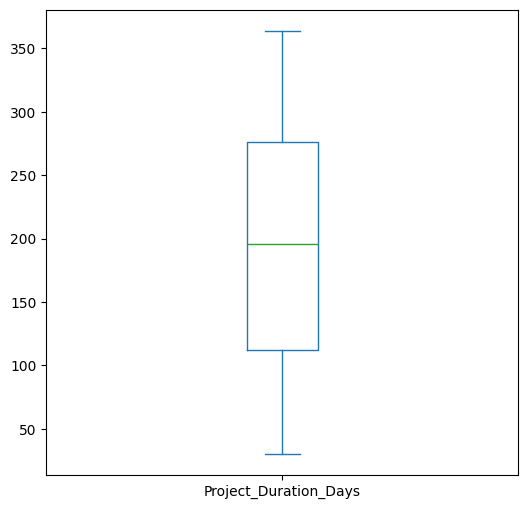

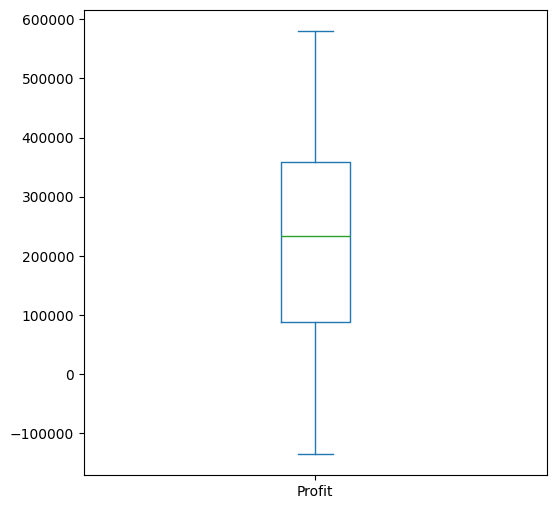

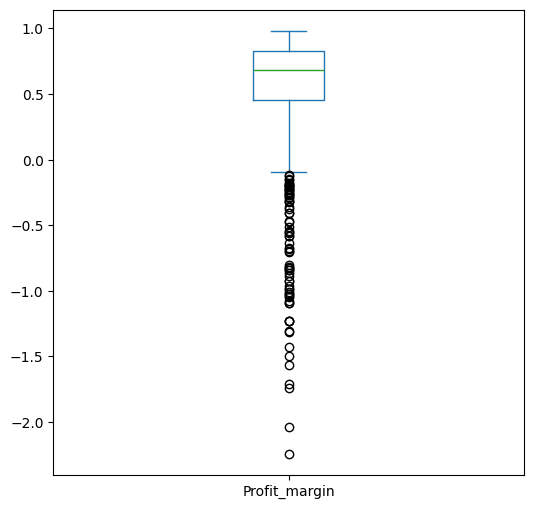

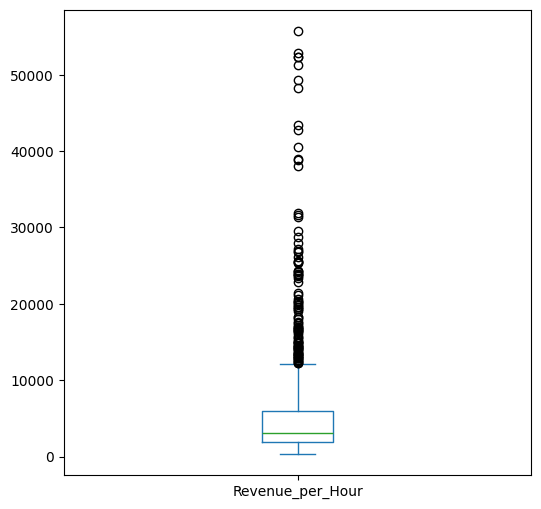

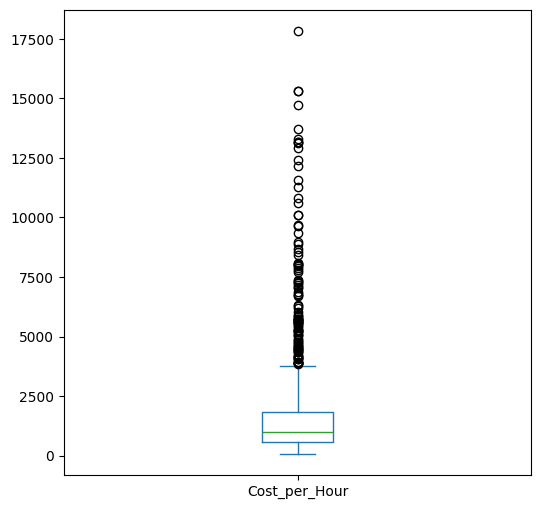

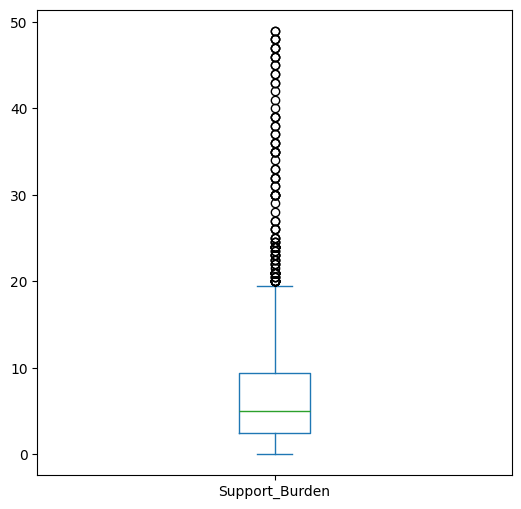

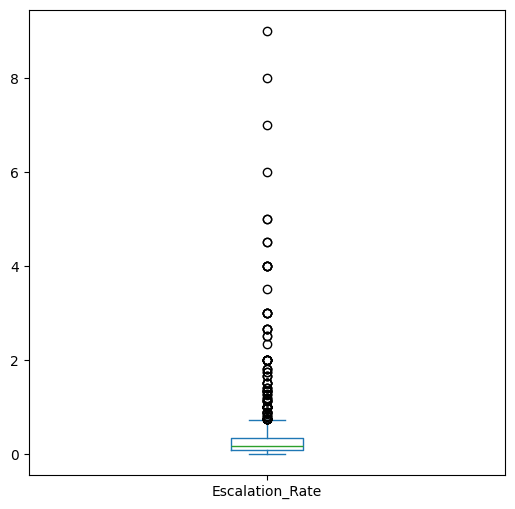

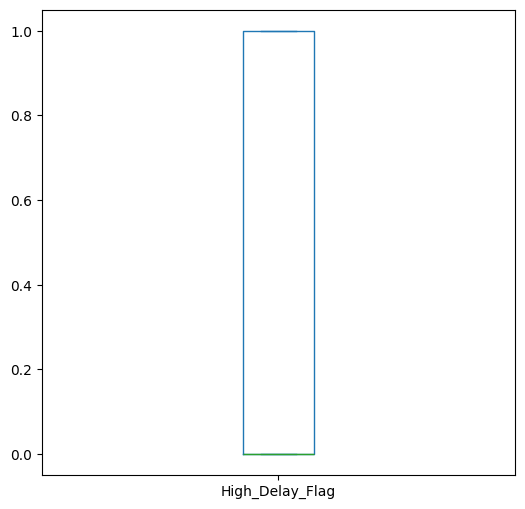

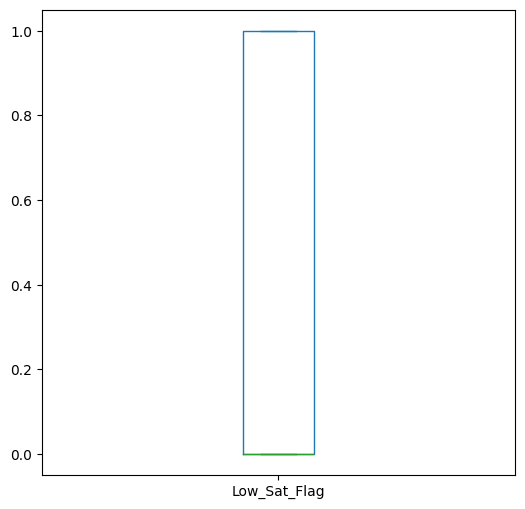

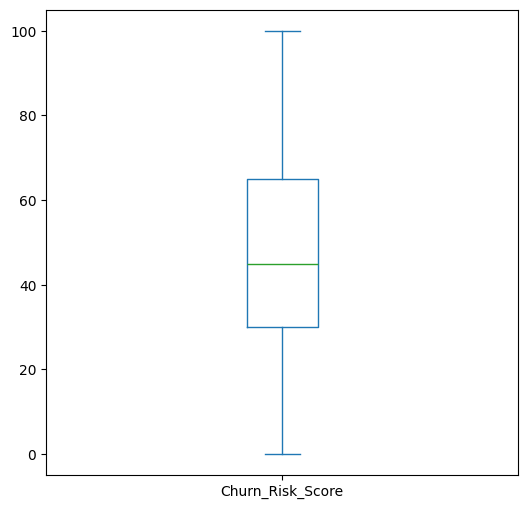

In [84]:
for i in numerical_data_after_DC:
    df[i].plot(kind='box', subplots=True, layout=(2, 4), figsize=(20, 10))
    plt.tight_layout()
    plt.show()

I haven't gone for second outlier treatment, as I personally beleive these outliers are not mistakes, these are real raw data, If I change or drop it, it may deviate the overall analysis

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Client_ID              1000 non-null   int64  
 1   Sector                 1000 non-null   str    
 2   Region                 1000 non-null   str    
 3   Project_Type           1000 non-null   str    
 4   Subscription_Type      1000 non-null   str    
 5   Contract_Value         1000 non-null   int64  
 6   Monthly_Revenue        1000 non-null   int64  
 7   Total_Revenue          1000 non-null   int64  
 8   Employee_Hours         1000 non-null   int64  
 9   Hourly_Rate            1000 non-null   int64  
 10  Operational_Cost       1000 non-null   int64  
 11  Support_Tickets        1000 non-null   int64  
 12  Escalations            1000 non-null   int64  
 13  Client_Tenure_Months   1000 non-null   int64  
 14  Satisfaction_Score     1000 non-null   float64
 15  Renewal_Status  

In [90]:
df.to_csv('client_profitability_final_for_dashboard.csv', index=False)
print("✅ Complete dataset saved!")

✅ Complete dataset saved!
